# Analisis de reseñas de `miempresa`

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias

Si te falta alguna libreria, puedes instalarla con:

```bash
pip install datasets pandas numpy scikit-learn transformers torch
```

In [2]:
import re
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [32]:
MAX_ROWS = None  # Ejemplo: 5000 para pruebas rapidas
TARGET ="justpark.com"
CAT = "Vehicles & Transportation"
N_TOPICS = 6
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset desde Hugging Face y lo convertimos a DataFrame.

In [18]:
df = pd.read_csv("Data/trustpilot-reviews-123k.csv")
df_emp = pd.read_excel("Data/emp_100_reviews.xlsx")

print("Shape reseñas", df.shape)
print("Shape empresas validas:", df_emp.shape)


Shape reseñas (123181, 6)
Shape empresas validas: (558, 6)


In [4]:
#df.to_csv('trustpilot-reviews-123k.csv', index=False)

## 4) Observamos qué tipo de caracteres hay 
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza. 

In [5]:
# Muestra aleatoria para ver con tus propios ojos
df['review'].sample(10).tolist()

# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

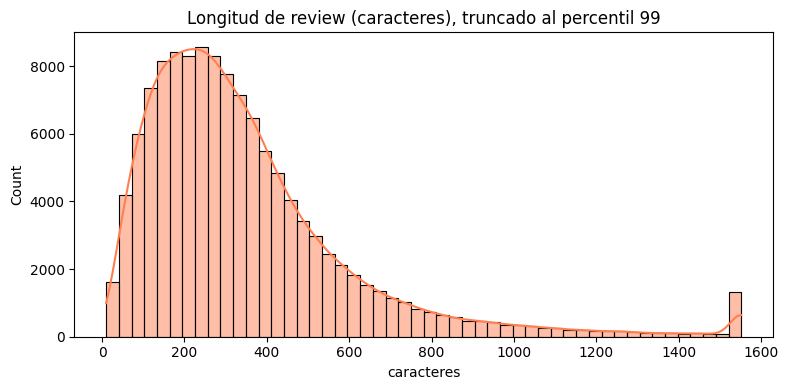

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

In [ ]:
# ver que tipos de caracteres tenemos para construir la funcion de limpieza: hastags, emojis, urls, menciones, saltos de linea, signos de puntuacion, numeros, etc


## 5) Observamos que tipos de caracteres tenemos y Construimos la funcion de limpieza



In [19]:
sample_reviews = df["review"].dropna().sample(5, random_state=42).tolist()

for i, review in enumerate(sample_reviews, 1):
    print(f"\n--- Review {i} ---")
    print(review[:1000])


--- Review 1 ---
Your wool is great value, the only thing I can comment on is that the wool was not bagged inside for protection.

--- Review 2 ---
I booked this intensive course in July last year… didn’t start my lessons until November because my first instructor was 2 hours late and didn’t pick up the phone and by the time I had got through to national intensive it was too late for me to have my lesson as I had to go to work. My second instructor then would fall asleep as I was driving and when I was unable to make a lesson and gave him the correct amount of notice, he threatened that if I didn’t pay him he would cancel my driving test which was only 10 days away. I had a back and forth with the national intensive course until they decided that I would loose my money for that lesson even though I gave the required amount of notice before cancelling.

--- Review 3 ---
Superb software at a market leading price. Very intuitive and once all set up for you it saves you hours of accountin

In [21]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

## 6) Filtrado del sector de la compañía objetivo

Primero filtramos la empresa objetivo seleccionada (`justpark.com`) y después obtenemos el conjunto de empresas de la misma categoría (`Transportation & Parking`) para poder comparar resultados.

In [28]:
df_target = df[df["company"].str.lower() == TARGET.lower()].copy()

print("Shape empresa objetivo:", df_target.shape)
df_target.head()

Shape empresa objetivo: (100, 6)


,category,company,description,title,review,stars
122356,Vehicles & Transportation,justpark.com,JustPark makes parking easier for over 13 mill...,Central London Parking - Excellent,Very easy to book via Just Park website/App. p...,5
122357,Vehicles & Transportation,justpark.com,JustPark makes parking easier for over 13 mill...,Never used this service before for…,Never used this service before for London but ...,5
122358,Vehicles & Transportation,justpark.com,JustPark makes parking easier for over 13 mill...,Easy to use,We used Just Park to find 24h parking in Paddi...,5
122359,Vehicles & Transportation,justpark.com,JustPark makes parking easier for over 13 mill...,Excellent car park situated just a…,Excellent car park situated just a couple of m...,5
122360,Vehicles & Transportation,justpark.com,JustPark makes parking easier for over 13 mill...,Satisfied Customer,This was the second time that I’ve used JustPa...,5


In [29]:
df_target["category"].value_counts()

category
Vehicles & Transportation    100
Name: count, dtype: int64

In [33]:
df_cat = df[df["category"].str.contains("transport", case=False, na=False)].copy()

print("Shape categoría:", df_cat.shape)
df_cat["company"].value_counts().head(20)

Shape categoría: (5765, 6)


company
www.autowindscreens.co.uk     100
www.nationalexpress.com       100
www.poferries.com             100
www.planetx.co.uk             100
www.protyre.co.uk             100
www.brittany-ferries.co.uk    100
taxis.gatwickairport.com      100
flixbus.co.uk                 100
www.kwik-fit.com              100
www.thetrainline.com          100
www.leisurelakesbikes.com     100
www.national.co.uk            100
www.ferryonline.co.uk         100
www.halfords.com              100
www.blackcircles.com          100
www.balfesbikes.co.uk         100
www.merlincycles.com          100
tyresonthedrive.com           100
www.winstanleysbikes.co.uk    100
www.sportandleisure.com       100
Name: count, dtype: int64

In [35]:
df_cat["company"].value_counts().head(20)

company
www.autowindscreens.co.uk     100
www.nationalexpress.com       100
www.poferries.com             100
www.planetx.co.uk             100
www.protyre.co.uk             100
www.brittany-ferries.co.uk    100
taxis.gatwickairport.com      100
flixbus.co.uk                 100
www.kwik-fit.com              100
www.thetrainline.com          100
www.leisurelakesbikes.com     100
www.national.co.uk            100
www.ferryonline.co.uk         100
www.halfords.com              100
www.blackcircles.com          100
www.balfesbikes.co.uk         100
www.merlincycles.com          100
tyresonthedrive.com           100
www.winstanleysbikes.co.uk    100
www.sportandleisure.com       100
Name: count, dtype: int64

In [37]:
competitors = [
    "www.thetrainline.com",
    "www.nationalexpress.com",
    "flixbus.co.uk"
]

df_comp = df[df["company"].isin(competitors)].copy()

print("Shape competidores:", df_comp.shape)
df_comp["company"].value_counts()

Shape competidores: (300, 6)


company
www.nationalexpress.com    100
flixbus.co.uk              100
www.thetrainline.com       100
Name: count, dtype: int64

## 7) Sentimiento
Aplicamos la funcion de limpieza y el sentiiento


In [39]:
def sentiment_label(stars):
    if stars >= 4:
        return "positivo"
    elif stars <= 2:
        return "negativo"
    else:
        return "neutral"

In [40]:
df_comp["sentiment"] = df_comp["stars"].apply(sentiment_label)

df_target["sentiment"] = df_target["stars"].apply(sentiment_label)

In [41]:
df_target["title"] = df_target["title"].fillna("")
df_target["review"] = df_target["review"].fillna("")

df_target["text"] = df_target["title"] + " " + df_target["review"]
df_target["clean_text"] = df_target["text"].apply(clean_text)

df_target[["stars", "sentiment", "text", "clean_text"]].head()

,stars,sentiment,text,clean_text
122356,5,positivo,Central London Parking - Excellent Very easy t...,central london parking excellent very easy to ...
122357,5,positivo,Never used this service before for… Never used...,never used this service before for never used ...
122358,5,positivo,Easy to use We used Just Park to find 24h park...,easy to use we used just park to find h parkin...
122359,5,positivo,Excellent car park situated just a… Excellent ...,excellent car park situated just a excellent c...
122360,5,positivo,Satisfied Customer This was the second time th...,satisfied customer this was the second time th...


In [42]:
df_target["sentiment"].value_counts()

sentiment
positivo    40
negativo    40
neutral     20
Name: count, dtype: int64

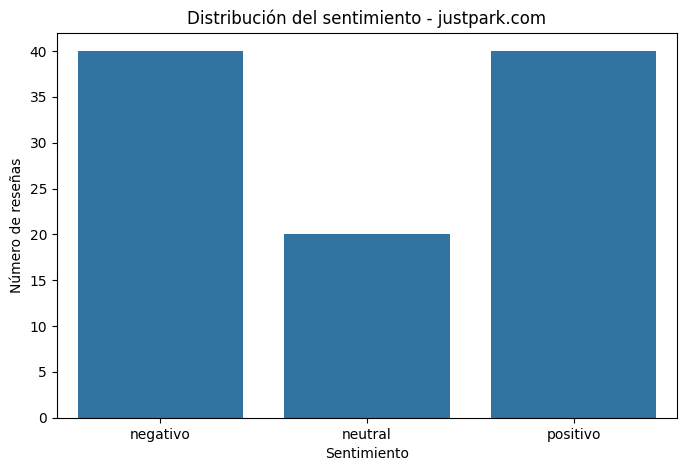

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(x="sentiment", data=df_target, order=["negativo", "neutral", "positivo"])
plt.title(f"Distribución del sentimiento - {TARGET}")
plt.xlabel("Sentimiento")
plt.ylabel("Número de reseñas")
plt.show()

In [44]:
df_compare = pd.concat([
    df_target[["company", "sentiment"]],
    df_comp[["company", "sentiment"]]
])

In [45]:
sentiment_comparison = pd.crosstab(
    df_compare["company"],
    df_compare["sentiment"],
    normalize="index"
)

sentiment_comparison

sentiment,negativo,neutral,positivo
company,,,
flixbus.co.uk,0.4,0.2,0.4
justpark.com,0.4,0.2,0.4
www.nationalexpress.com,0.4,0.2,0.4
www.thetrainline.com,0.4,0.2,0.4


## Comparación con la competencia

En este apartado se compara la distribución de sentimiento entre justpark.com y varias empresas del sector transporte.

Esto permite evaluar si la percepción del cliente es mejor, peor o similar respecto a sus competidores.

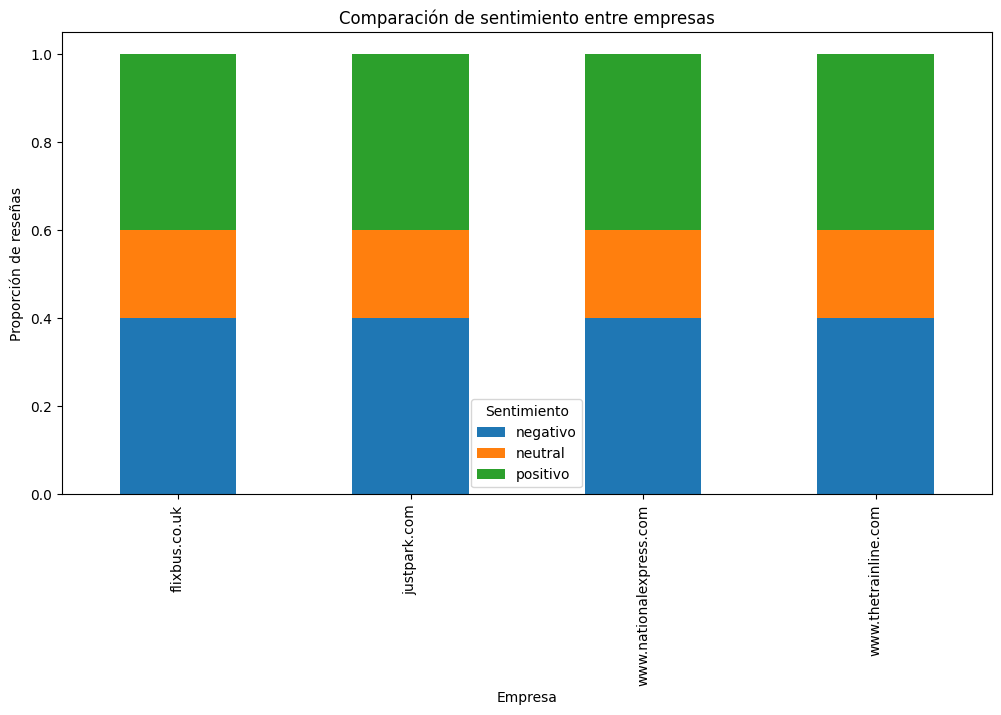

In [46]:
sentiment_comparison[["negativo", "neutral", "positivo"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Comparación de sentimiento entre empresas")
plt.xlabel("Empresa")
plt.ylabel("Proporción de reseñas")
plt.legend(title="Sentimiento")
plt.show()

## Interpretación de resultados

Se observa que todas las empresas presentan exactamente la misma distribución de sentimiento (40% positivo, 40% negativo y 20% neutral).

Esto sugiere que el dataset está balanceado artificialmente, por lo que no refleja diferencias reales entre empresas.

Aun así, este análisis permite validar la metodología y continuar con el estudio de los temas (topics) presentes en las reseñas.

## 8) Topics

En este apartado se identifican los temas principales presentes en las reseñas de justpark.com.

Para ello se utiliza TF-IDF para transformar el texto en formato numérico y NMF para extraer los temas más relevantes.


In [47]:
#%pip install --no-deps bertopic
#%pip install --upgrade numpy hdbscan umap-learn pandas scikit-learn tqdm plotly pyyaml
# Y reinicia kernel
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X_text = vectorizer.fit_transform(df_target["clean_text"])

print(X_text.shape)

(100, 1000)


In [49]:
nmf = NMF(n_components=N_TOPICS, random_state=42,max_iter=500)

W = nmf.fit_transform(X_text)
H = nmf.components_

C:\Users\xaviserentill\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


In [50]:
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(H):
    top_words = [feature_names[i] for i in topic.argsort()[-TOP_WORDS:]]
    print(f"Topic {topic_idx + 1}: {top_words}")

Topic 1: ['experience', 'cancelled', 'park', 'paid', 'left', 'booking', 'arrived', 'car', 'spot', 'booked', 'parking', 'space']
Topic 2: ['did', 'central', 'easy', 'secure', 'just', 'pay', 'use', 'london', 'used', 'excellent', 'app', 'parking']
Topic 3: ['press', 'garage', 'button', 'provided', 'location', 'barrier', 'nice', 'enter', 'exit', 'gate', 'code', 'open']
Topic 4: ['inexpensive', 'tight', 'like', 'driveway', 'allocated', 'plenty', 'didn', 'difficult', 'hotel', 'car', 'spaces', 'park']
Topic 5: ['definitely', 'safe', 'directions', 'clear', 'access', 'book', 'use', 'booking', 'time', 'using', 'justpark', 'easy']
Topic 6: ['park', 'reasonable', 'service', 'instructions', 'thank', 'fine', 'parking', 'good', 'hour', 'location', 'price', 'great']


## Interpretación de Topics

A partir de las palabras clave obtenidas, se pueden identificar los siguientes temas principales:

- **Topic 1 – Problemas en reservas y cancelaciones**  
  Incluye términos como "cancelled", "paid", "booking", lo que sugiere incidencias relacionadas con pagos o reservas.

- **Topic 2 – Facilidad de uso y experiencia positiva**  
  Palabras como "easy", "secure", "excellent" indican una experiencia positiva y uso sencillo de la plataforma.

- **Topic 3 – Acceso físico al parking**  
  Incluye "garage", "barrier", "gate", lo que refleja problemas o experiencias relacionadas con la entrada y salida.

- **Topic 4 – Precio y disponibilidad**  
  Términos como "inexpensive", "spaces", "difficult" sugieren temas relacionados con el coste y la disponibilidad de plazas.

- **Topic 5 – Navegación y uso de la plataforma**  
  Incluye "directions", "access", "justpark", lo que apunta a la experiencia de uso y orientación.

- **Topic 6 – Servicio general y satisfacción**  
  Palabras como "service", "good", "price", "location" reflejan valoraciones generales del servicio.

In [52]:
df_target["topic"] = W.argmax(axis=1)
topic_sentiment = pd.crosstab(
    df_target["topic"],
    df_target["sentiment"],
    normalize="index"
)

topic_sentiment

sentiment,negativo,neutral,positivo
topic,,,
0,0.733333,0.200000,0.066667
1,0.315789,0.157895,0.526316
2,0.500000,0.166667,0.333333
3,0.470588,0.294118,0.235294
4,0.157895,0.157895,0.684211
5,0.333333,0.222222,0.444444


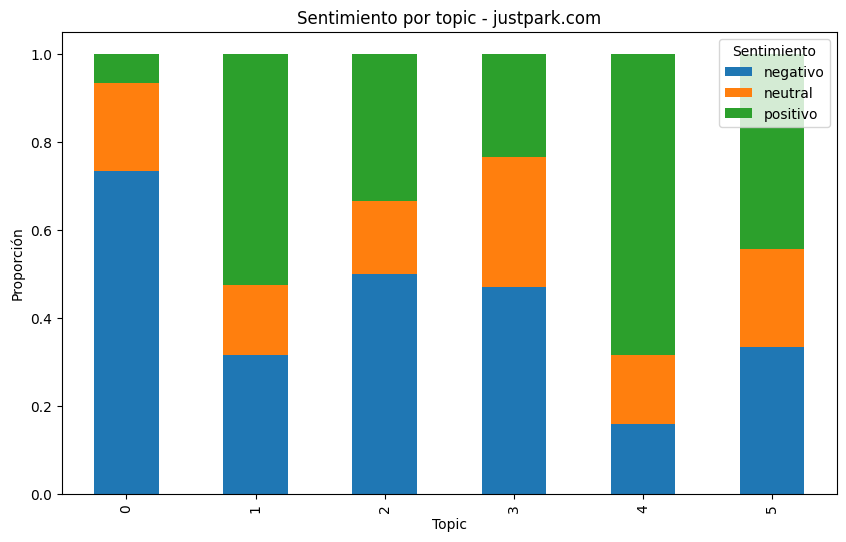

In [53]:
topic_sentiment[["negativo", "neutral", "positivo"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Sentimiento por topic - justpark.com")
plt.xlabel("Topic")
plt.ylabel("Proporción")
plt.legend(title="Sentimiento")
plt.show()

## Relación entre topics y sentimiento

El análisis muestra que algunos temas están más asociados a experiencias negativas, como los problemas en reservas o accesos, mientras que otros, como la facilidad de uso o el servicio general, presentan un mayor porcentaje de valoraciones positivas.

Esto permite identificar áreas de mejora y fortalezas del servicio.

# 9) Visualizaciones

Se muestra la distribución de los topics en las reseñas, lo que permite identificar cuáles son los temas más frecuentes en la experiencia del cliente.

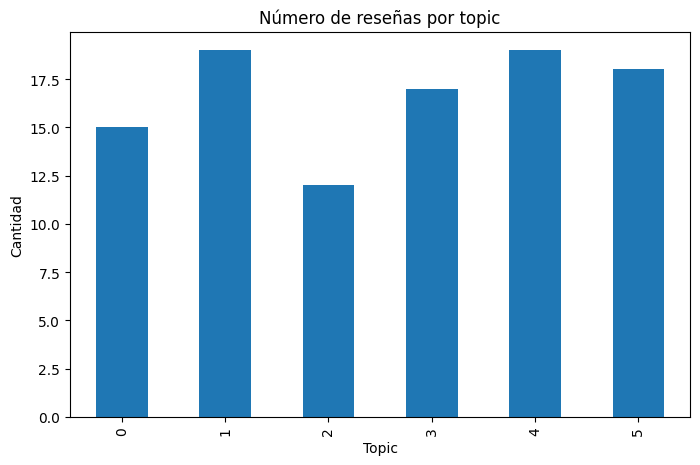

In [55]:
#%pip install wordcloud
df_target["topic"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Número de reseñas por topic")
plt.xlabel("Topic")
plt.ylabel("Cantidad")
plt.show()

### Longitud de las reseñas según el sentimiento

Se analiza si existe relación entre la longitud de las reseñas y el sentimiento expresado por los usuarios.

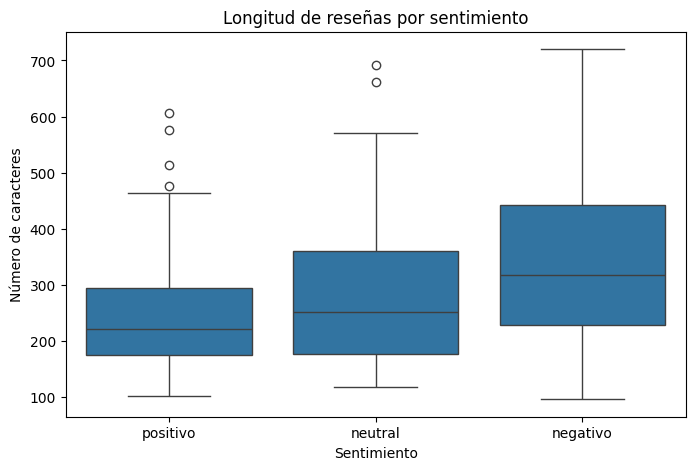

In [56]:
df_target["review_len"] = df_target["review"].astype(str).str.len()

plt.figure(figsize=(8,5))
sns.boxplot(x="sentiment", y="review_len", data=df_target)

plt.title("Longitud de reseñas por sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Número de caracteres")
plt.show()

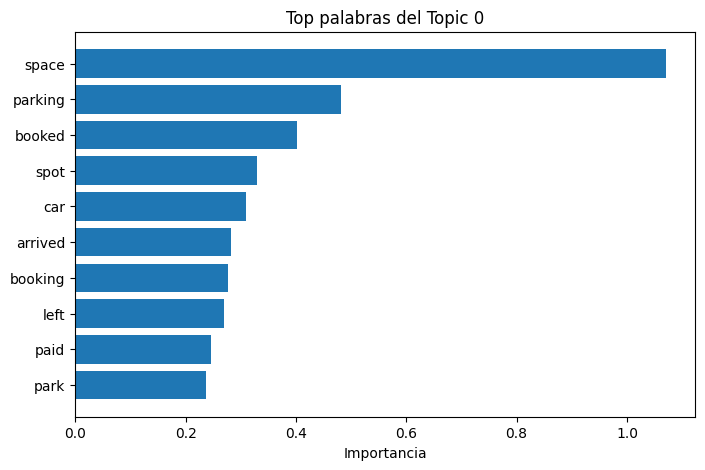

In [57]:
topic_id = 0

words = [feature_names[i] for i in H[topic_id].argsort()[-10:]]
values = H[topic_id][H[topic_id].argsort()[-10:]]

plt.figure(figsize=(8,5))
plt.barh(words, values)

plt.title(f"Top palabras del Topic {topic_id}")
plt.xlabel("Importancia")
plt.show()

## Conclusión

El análisis realizado permite identificar los principales factores que influyen en la experiencia del cliente en justpark.com. 

Aunque el sentimiento aparece equilibrado debido a la naturaleza del dataset, el estudio de los topics revela aspectos clave como problemas en reservas, facilidad de uso, acceso al parking y valoración general del servicio.

En conjunto, la metodología aplicada permite no solo analizar el sentimiento de las reseñas, sino también entender qué elementos impactan en la satisfacción del cliente, aportando información útil para la toma de decisiones.